In [69]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import inspect

In [70]:
metadata = load_dataset("th1nhng0/vietnamese-legal-documents", "metadata")

In [71]:
print(metadata['data'].features)


{'id': Value(dtype='int64', id=None), 'title': Value(dtype='string', id=None), 'so_ky_hieu': Value(dtype='string', id=None), 'ngay_ban_hanh': Value(dtype='string', id=None), 'loai_van_ban': Value(dtype='string', id=None), 'ngay_co_hieu_luc': Value(dtype='string', id=None), 'ngay_het_hieu_luc': Value(dtype='string', id=None), 'nguon_thu_thap': Value(dtype='string', id=None), 'ngay_dang_cong_bao': Value(dtype='string', id=None), 'nganh': Value(dtype='string', id=None), 'linh_vuc': Value(dtype='string', id=None), 'co_quan_ban_hanh': Value(dtype='string', id=None), 'chuc_danh': Value(dtype='string', id=None), 'nguoi_ky': Value(dtype='string', id=None), 'pham_vi': Value(dtype='string', id=None), 'thong_tin_ap_dung': Value(dtype='string', id=None), 'tinh_trang_hieu_luc': Value(dtype='string', id=None)}


In [72]:
metadata_df = metadata['data'].to_pandas()

In [73]:
metadata_df.head(5)

,id,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,ngay_het_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,thong_tin_ap_dung,tinh_trang_hieu_luc
0,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,103/SL,05/06/1950,Sắc lệnh,20/06/1950,NaN,Công báo số 7/1950;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ
1,4260,Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...,87/1999/QĐ-UB,12/07/1999,Quyết định,12/07/1999,NaN,STP tỉnh Lâm Đồng;,...,NaN,NaN,UBND tỉnh Lâm Đồng,Q.Chủ tịch,Đặng Đức Lợi,Lâm Đồng,NaN,Còn hiệu lực
2,4280,Về viẹc quản lý và quy định thống nhất phí chợ...,157/1999/QĐ-UB,19/11/1999,Quyết định,19/11/1999,NaN,STP tỉnh Lâm Đồng;,...,Tài chính,NaN,UBND tỉnh Lâm Đồng,Phó Chủ tịch,Trương Thành Trung,Lâm Đồng,NaN,Còn hiệu lực
3,4263,Về việc xử lý đối với quỹ nhà thuộc quyền sở h...,163/1999/QĐ-UB,30/11/1999,Quyết định,30/11/1999,NaN,STP tỉnh Lâm Đồng;,...,Xây dựng,NaN,UBND tỉnh Lâm Đồng,Q.Chủ tịch,Đặng Đức Lợi,Lâm Đồng,NaN,Còn hiệu lực
4,77,Sắc lệnh bãi bỏ Sắc lệnh 106 ngày 09-09-1949 v...,83/SL,22/05/1950,Sắc lệnh,01/05/1950,NaN,Hồ sơ số Q009-H002A/LTQG;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ


In [74]:
# Extract only education-related, nation-wide scope and still effective metadata
education_metadata = metadata_df[(metadata_df['nganh'] == 'Giáo dục và đào tạo') & (metadata_df['tinh_trang_hieu_luc'] == 'Còn hiệu lực') & (metadata_df['pham_vi'] == 'Toàn quốc')]
print(education_metadata.shape)

(530, 17)


In [75]:
education_metadata.head(5)

,id,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,ngay_het_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,thong_tin_ap_dung,tinh_trang_hieu_luc
201,2221,"Về học bổng, học phí của học sinh các trường đ...",63-HĐBT,10/06/1989,Quyết định,10/06/1989,NaN,Công báo số 12/1989;,...,Giáo dục và đào tạo,NaN,Hội đồng Bộ trưởng,Chủ tịch hội đồng bộ trưởng,Võ Văn Kiệt,Toàn quốc,NaN,Còn hiệu lực
426,6273,Về việc ban hành Điều lệ Trường trung học,23/2000/QĐ-BGD,11/07/2000,Quyết định,26/07/2000,...,"Công báo số 32, năm 2000",31/08/2000,Giáo dục và đào tạo,NaN,Bộ Giáo dục và Đào tạo,Bộ trưởng,Nguyễn Minh Hiển,Toàn quốc,NaN,Còn hiệu lực
510,6264,Về việc ban hành tạm thời chương trình Đại học...,02/2000/QĐ-BGD,04/03/2000,Quyết định,19/03/2000,NaN,Công báo điện tử;,...,Giáo dục và đào tạo,NaN,Bộ Giáo dục và Đào tạo,Bộ trưởng,Nguyễn Minh Hiển,Toàn quốc,NaN,Còn hiệu lực
929,1993,"Về việc sửa đổi, bổ sung quy định về thu học p...",217-HĐBT,13/06/1990,Quyết định,13/06/1990,NaN,Công báo số 13/1990;,...,Giáo dục và đào tạo,NaN,Hội đồng Bộ trưởng,Chủ tịch hội đồng bộ trưởng,Võ Văn Kiệt,Toàn quốc,NaN,Còn hiệu lực
984,1927,Về việc công nhận trường Đại học Tuyên giáo,406-HĐBT,20/11/1990,Quyết định,20/11/1990,NaN,Công báo số 24/1990;,...,Giáo dục và đào tạo,NaN,Hội đồng Bộ trưởng,Chủ tịch hội đồng bộ trưởng,Nguyễn Khánh,Toàn quốc,NaN,Còn hiệu lực


# EDA

## Metadata

In [76]:
import matplotlib.pyplot as plt

In [77]:
education_metadata.info()

<class 'pandas.DataFrame'>
Index: 530 entries, 201 to 153134
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id                   530 non-null    int64
 1   title                530 non-null    str  
 2   so_ky_hieu           530 non-null    str  
 3   ngay_ban_hanh        530 non-null    str  
 4   loai_van_ban         530 non-null    str  
 5   ngay_co_hieu_luc     530 non-null    str  
 6   ngay_het_hieu_luc    9 non-null      str  
 7   nguon_thu_thap       271 non-null    str  
 8   ngay_dang_cong_bao   530 non-null    str  
 9   nganh                530 non-null    str  
 10  linh_vuc             82 non-null     str  
 11  co_quan_ban_hanh     528 non-null    str  
 12  chuc_danh            528 non-null    str  
 13  nguoi_ky             529 non-null    str  
 14  pham_vi              530 non-null    str  
 15  thong_tin_ap_dung    0 non-null      str  
 16  tinh_trang_hieu_luc  530 non-null    

In [79]:
# Change the 'ngay_ban_hanh' column to datetime format
education_metadata['ngay_ban_hanh'] = pd.to_datetime(education_metadata['ngay_ban_hanh'], dayfirst= True, errors='raise')

In [80]:
# The first date and the last date in the dataset
print("First date:", education_metadata['ngay_ban_hanh'].min())
print("Last date:", education_metadata['ngay_ban_hanh'].max())
# Add year of issue as a new column
education_metadata['year_of_issue'] = education_metadata['ngay_ban_hanh'].dt.year
print(education_metadata['year_of_issue'].value_counts().iloc[[0]])

First date: 1960-03-19 00:00:00
Last date: 2026-03-02 00:00:00
year_of_issue
2006    43
Name: count, dtype: int64


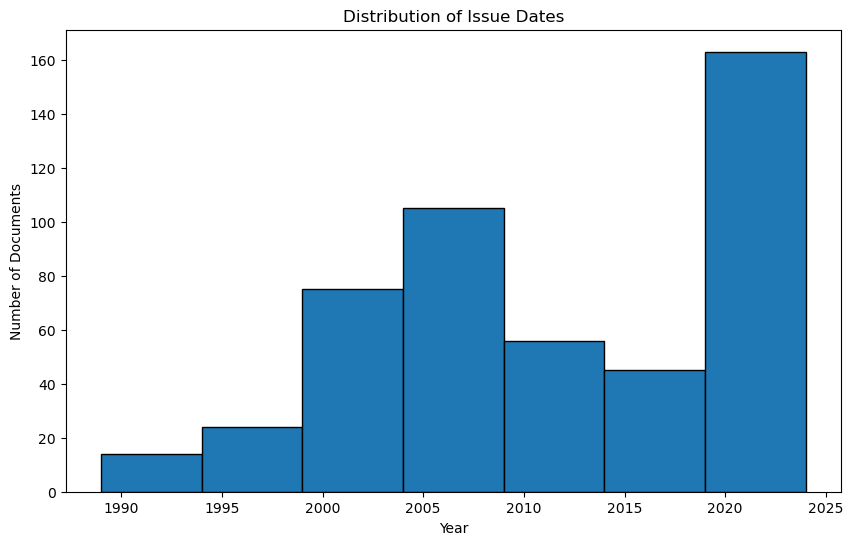

In [81]:
# Plot the distribution of the issue dates of the documents, with bins of 5 years
plt.figure(figsize=(10, 6))
plt.hist(education_metadata['year_of_issue'].dropna(), bins=range(1989, 2026, 5), edgecolor='black')
plt.title('Distribution of Issue Dates')
plt.xlabel('Year')
plt.ylabel('Number of Documents')
plt.show()


In [82]:
# Drop the 'thong_tin_ap_dung' because it contains too many missing values
education_metadata = education_metadata.drop(columns=['thong_tin_ap_dung'])
education_metadata.info()


<class 'pandas.DataFrame'>
Index: 530 entries, 201 to 153134
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   530 non-null    int64         
 1   title                530 non-null    str           
 2   so_ky_hieu           530 non-null    str           
 3   ngay_ban_hanh        530 non-null    datetime64[us]
 4   loai_van_ban         530 non-null    str           
 5   ngay_co_hieu_luc     530 non-null    str           
 6   ngay_het_hieu_luc    9 non-null      str           
 7   nguon_thu_thap       271 non-null    str           
 8   ngay_dang_cong_bao   530 non-null    str           
 9   nganh                530 non-null    str           
 10  linh_vuc             82 non-null     str           
 11  co_quan_ban_hanh     528 non-null    str           
 12  chuc_danh            528 non-null    str           
 13  nguoi_ky             529 non-null    str      

In [83]:
# Remove the index of the dataframe and reset it to start from 0
education_metadata.reset_index(drop=True, inplace=True)

In [ ]:
# Inspect the 'nguon_thu_thap' column
print(education_metadata['nguon_thu_thap'].value_counts(ascending = False).iloc[0:5])
# List all the variable in the 'nguon_thu_thap' column
print(education_metadata['nguon_thu_thap'].unique().tolist())
# Remove the documents coming from invalid sources
invalid_sources = ['Danh mục các văn bản quy phạm pháp luật đã bị bãi bỏ']
education_metadata = education_metadata[~education_metadata['nguon_thu_thap'].isin(invalid_sources)]

nguon_thu_thap
bản lưu                                                  23
Công báo điện tử;                                        15
Công báo CP                                               5
Công báo số 15+16, năm 2006                               3
Danh mục các văn bản quy phạm pháp luật đã bị bãi bỏ;     2
Name: count, dtype: int64
['Công báo số 12/1989;', 'Công báo số 32, năm 2000', 'Công báo điện tử;', 'Công báo số 13/1990;', 'Công báo số 24/1990;', 'Công báo điện tử; Số 24', 'Công báo điện tử; số 33', 'Công báo số 24/1989;', 'Danh mục các văn bản quy phạm pháp luật đã bị bãi bỏ;', 'Công báo số 42, năm 1999', 'Công báo số 1/1990;', 'Công báo số 9/1990;', 'Công báo số 32', 'Công báo số 13, năm 1999', 'Công báo điện tử số 21;', 'Công báo số 31', 'Công báo số 4, năm 1997', 'Công báo số 20', 'Công báo số 2, ngày 20/01/1998;', 'Công báo số 4, ngày 10/02/1998;', 'Công báo số 14, năm 1996', 'Công báo số 23', 'Công báo số 25', 'Công báo số 1', 'Công báo số 11/1992;', 'Công báo số 10/1

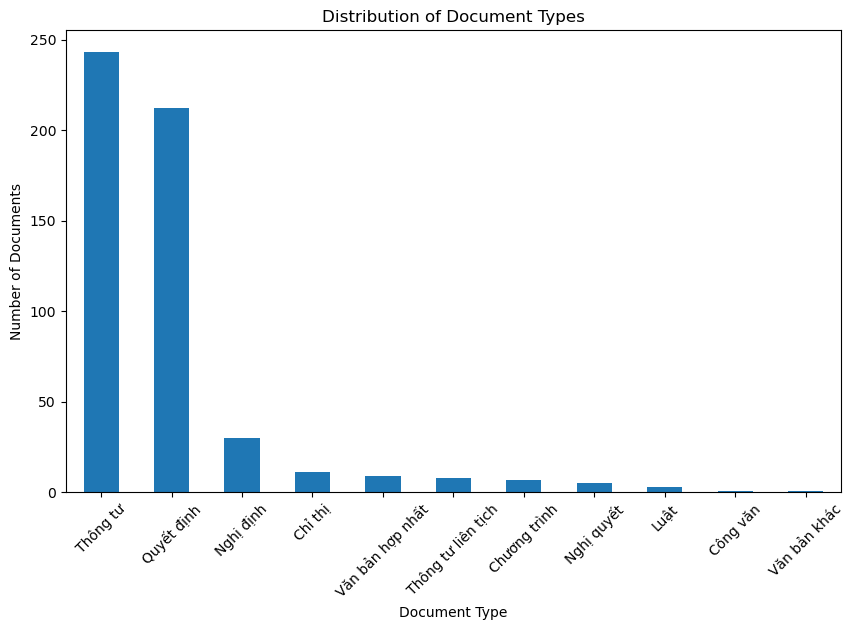

In [98]:
# Plot the distribution of 'loai_van_ban' in the education metadata
plt.figure(figsize=(10, 6))
education_metadata['loai_van_ban'].value_counts().plot(kind='bar')
plt.title('Distribution of Document Types')
plt.xlabel('Document Type')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)
plt.show()

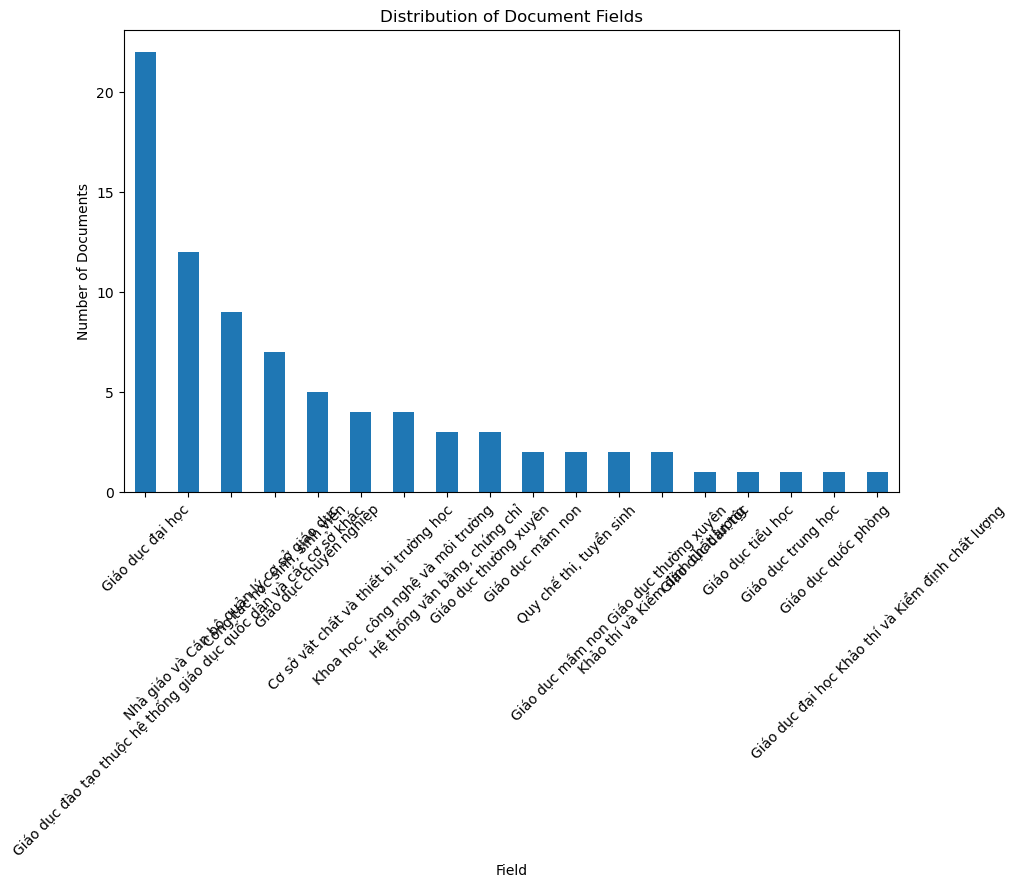

In [101]:
# Plot the distribution of 'linh_vuc' column
plt.figure(figsize = (10,6))
education_metadata['linh_vuc'].value_counts(dropna = True).plot(kind ='bar')
plt.title('Distribution of Document Fields')
plt.xlabel('Field')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)
plt.show()

In [104]:
education_metadata['linh_vuc'].value_counts(dropna = True, ascending = False).iloc[0:]

linh_vuc
Giáo dục đại học                                                       22
Giáo dục đào tạo thuộc hệ thống giáo dục quốc dân và các cơ sở khác    12
Nhà giáo và Cán bộ quản lý cơ sở giáo dục                               9
Công tác học sinh, sinh viên                                            7
Giáo dục chuyên nghiệp                                                  5
Cơ sở vật chất và thiết bị trường học                                   4
Khoa học, công nghệ và môi trường                                       4
Hệ thống văn bằng, chứng chỉ                                            3
Giáo dục thường xuyên                                                   3
Giáo dục mầm non                                                        2
Quy chế thi, tuyển sinh                                                 2
Giáo dục mầm non Giáo dục thường xuyên                                  2
Khảo thí và Kiểm định chất lượng                                        2
Giáo dục dân tộc             

In [108]:
# Filter out the documents with missing 'linh_vuc' values
education_metadata[(~education_metadata['linh_vuc'].isnull()) & (education_metadata['year_of_issue'] < 2000)].head(5)

,id,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,ngay_het_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,tinh_trang_hieu_luc,year_of_issue
32,9958,Về việc xây dựng 3 trường phổ thông trung học ...,89/TTg,1995-01-17,Quyết định,17/01/1995,NaN,Công báo điện tử;,...,Giáo dục và đào tạo,Cơ sở vật chất và thiết bị trường học,Chính phủ,Thủ tướng Chính phủ,Võ Văn Kiệt,Toàn quốc,Còn hiệu lực,1995
38,9668,Về việc nâng cấp Trường Trung học Văn hoá Nghệ...,618/TTg,1995-09-28,Quyết định,28/09/1995,NaN,Công báo,...,Giáo dục và đào tạo,Giáo dục đại học,Thủ tướng Chính phủ,Thủ tướng Chính phủ,Nguyễn Khánh,Toàn quốc,Còn hiệu lực,1995
42,10673,Về việc thành lập Đại học mở bán công thành ph...,389-TTg,1993-07-26,Quyết định,26/07/1993,NaN,Công báo số 17/1993;,...,Giáo dục và đào tạo,Giáo dục đại học,Thủ tướng Chính phủ,Thủ tướng,Nguyễn Khánh,Toàn quốc,Còn hiệu lực,1993
48,9163,Về việc nâng cấp trường Trung học kỹ thuật mỏ ...,479/TTg,1996-07-24,Quyết định,24/07/1996,NaN,Công báo điện tử số 21 ngày 15/11/1996,15/11/1996,Giáo dục và đào tạo,Giáo dục chuyên nghiệp,Thủ tướng Chính phủ,Thủ tướng,Nguyễn Khánh,Toàn quốc,Còn hiệu lực,1996
49,9162,Về việc nâng cấp trường Trung học giao thông v...,480/TTg,1996-07-24,Quyết định,24/07/1996,NaN,Công báo điện tử số 22 ngày 30/11/1996,30/11/1996,Giáo dục và đào tạo,Giáo dục chuyên nghiệp,Thủ tướng Chính phủ,Thủ tướng,Nguyễn Khánh,Toàn quốc,Còn hiệu lực,1996


In [110]:
len(education_metadata[(~education_metadata['linh_vuc'].isnull()) & (education_metadata['year_of_issue'] < 2000)])

9

In [111]:
import re

patterns = {
    'Giáo dục đại học': re.compile(r'đại\s*học', re.IGNORECASE),
    'Giáo dục mầm non': re.compile(r'mầm\s*non', re.IGNORECASE),
    'Giáo dục tiểu học': re.compile(r'tiểu\s*học', re.IGNORECASE),
    'Giáo dục trung học': re.compile(r'trung\s*học', re.IGNORECASE),
    'Giáo dục thường xuyên': re.compile(r'thường\s*xuyên', re.IGNORECASE),
    'Giáo dục chuyên nghiệp': re.compile(r'chuyên\s*nghiệp', re.IGNORECASE),
    
    'Nhà giáo và Cán bộ quản lý cơ sở giáo dục': re.compile(r'nhà\s*giáo|cán\s*bộ\s*quản\s*lý', re.IGNORECASE),
    'Công tác học sinh, sinh viên': re.compile(r'học\s*sinh|sinh\s*viên', re.IGNORECASE),
    
    'Cơ sở vật chất và thiết bị trường học': re.compile(r'cơ\s*sở\s*vật\s*chất|thiết\s*bị', re.IGNORECASE),
    'Hệ thống văn bằng, chứng chỉ': re.compile(r'văn\s*bằng|chứng\s*chỉ', re.IGNORECASE),
    
    'Quy chế thi, tuyển sinh': re.compile(r'thi|tuyển\s*sinh', re.IGNORECASE),
    'Khảo thí và Kiểm định chất lượng': re.compile(r'khảo\s*thí|kiểm\s*định', re.IGNORECASE),
    
    'Khoa học, công nghệ và môi trường': re.compile(r'khoa\s*học|công\s*nghệ|môi\s*trường', re.IGNORECASE),
    'Giáo dục dân tộc': re.compile(r'dân\s*tộc', re.IGNORECASE),
    'Giáo dục quốc phòng': re.compile(r'quốc\s*phòng', re.IGNORECASE),
}

def label_linh_vuc(title):
    if pd.isnull(title):
        return np.nan
    
    title = title.lower()
    
    for label, pattern in patterns.items():
        if re.search(pattern, title):
            return label   # return luôn → chỉ 1 label
    
    return np.nan

In [112]:
education_metadata['linh_vuc'] = education_metadata.apply(
    lambda row: label_linh_vuc(row['title']) if pd.isnull(row['linh_vuc']) else row['linh_vuc'],
    axis=1
)

In [113]:
# After labeling, check the distribution of 'linh_vuc' again
education_metadata['linh_vuc'].value_counts(dropna = True, ascending = False).iloc[0:]

linh_vuc
Giáo dục đại học                                                       158
Giáo dục trung học                                                      37
Giáo dục mầm non                                                        34
Công tác học sinh, sinh viên                                            22
Nhà giáo và Cán bộ quản lý cơ sở giáo dục                               21
Giáo dục thường xuyên                                                   17
Quy chế thi, tuyển sinh                                                 15
Khoa học, công nghệ và môi trường                                       12
Giáo dục đào tạo thuộc hệ thống giáo dục quốc dân và các cơ sở khác     12
Giáo dục dân tộc                                                        10
Hệ thống văn bằng, chứng chỉ                                            10
Giáo dục chuyên nghiệp                                                   9
Giáo dục tiểu học                                                        8
Cơ sở vật chất v

In [114]:
# Only keep the rows with field values related to university education and college education
university_fields = ['Giáo dục đại học', 'Giáo dục đại học Khảo thí và Kiểm định chất lượng', 'Quy chế thi, tuyển sinh']
university_education_metadata = education_metadata[education_metadata['linh_vuc'].isin(university_fields)]

In [115]:
# Export the files to csv
university_education_metadata.to_csv('data/raw/university_education_metadata.csv', index=False)

In [138]:
print(university_education_metadata.shape)
print(university_education_metadata['id'].nunique())

(174, 17)
174


In [126]:
df = pd.read_parquet("hf://datasets/th1nhng0/vietnamese-legal-documents/data/content.parquet")

In [127]:
df.head(5)

,id,content_html
0,4260,"<table class=""detailcontent"" width=""100%"" bord..."
1,4266,"<table class=""detailcontent"" width=""100%"" bord..."
2,4262,"<table class=""detailcontent"" width=""100%"" bord..."
3,4264,"<table class=""detailcontent"" width=""100%"" bord..."
4,4281,"<table class=""detailcontent"" width=""100%"" bord..."


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178665 entries, 0 to 178664
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            178665 non-null  int64
 1   content_html  178665 non-null  str  
dtypes: int64(1), str(1)
memory usage: 3.7 GB


In [141]:
# Check the number of unique ids in the content dataset
print(df['id'].nunique())
# Display the duplicate ids in the content dataset
duplicate_ids = df[df.duplicated(subset='id', keep=False)]['id']
print(duplicate_ids.head(5))

149051
0    4260
1    4266
2    4262
3    4264
4    4281
Name: id, dtype: int64


In [145]:
print(df.loc[4260, 'content_html'][:1000])

<table class="detailcontent" width="100%" border="0" id="content">
                <tr>
                    <td colspan="3">
                        <div align="justify">
                            <p align="center">
	<strong>THÔNG TƯ</strong></p>
<p align="center">
	<strong>Về việc thi hành chế độ thu quốc doanh đối với hoạt động thiết kế xây dựng</strong></p>
<p>
	<em>Căn cứ vào Thông tư số 47-TT/TC/TQD ngày 27-12-1985 của Bộ Tài chính về việc quy định chế độ thu quốc doanh; nay Bộ Tài chính hướng dẫn việc thi hành chế độ thu quốc doanh đối với hoạt động thiết kế xây dựng như sau:</em></p>
<p>
	<strong>1. Đối tượng nộp thu quốc doanh:</strong></p>
<p>
	- Những hoạt động thiết kế xây dựng như lập luận chứng kinh tế kỹ thuật, thiết kế lập dự toán công trình xây dựng cơ bản (kể cả thiết kế công trình văn hoá, nghệ thuật chi bằng vốn đầu tư xây dựng cơ bản) , thiết kế quy hoạch xây dựng... của các viện thiết kế, các xí nghiệp thiết kế, các xưởng, phòng hoặc trung tâm dịch vụ làm nhi


In [146]:
print(df.loc[4266, 'content_html'][:1000])

<table class="detailcontent" width="100%" border="0" id="content">
                <tr>
                    <td colspan="3">
                        <div align="justify">
                            <table border="0" cellpadding="0" style="width:100.0%;" width="100%">
	<tbody>
		<tr>
			<td>
				<p align="center">
					<strong>QUYẾT ĐỊNH</strong></p>
				<p align="center">
					<strong>Ân giảm thời hạn phạt tù</strong></p>
				<p align="center">
					HỘI ĐỒNG NHÀ NƯỚC</p>
				<p align="center">
					NƯỚC CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM</p>
				<p>
					<em>Căn cứ vào Điều 100 của Hiến pháp nước Cộng hoà xã hội chủ nghĩa Việt Nam ;</em></p>
				<p>
					<em>Căn cứ vào kết quả thi hành chính sách giáo dục và cải tạo của Nhà nước đối với phạm nhân và những người phải tập trung giáo dục cải tạo ;</em></p>
				<p>
					<em>Nhân dịp kỷ niệm lần thứ 42 ngày Quốc khánh 2-9 ;</em></p>
				<p>
					<em>Theo đề nghị của Hội đồng bộ trưởng ;</em></p>
				<p align="center">
					<strong>QUYẾ


In [131]:
# Change the id column to int64 type
df['id'] = df['id'].astype('int64')

In [ ]:
# Merge two dataset together
legal_docs = pd.merge(df, university_education_metadata, on='id', how = 'right')
print(legal_docs.shape)


(276, 18)


In [147]:
# Remove duplicate rows based on the 'id' column, keeping only the first occurrence
legal_docs = legal_docs.drop_duplicates(subset='id', keep='first')
print(legal_docs.shape)

(174, 18)


Text(0.5, 0, 'Year of Issue')

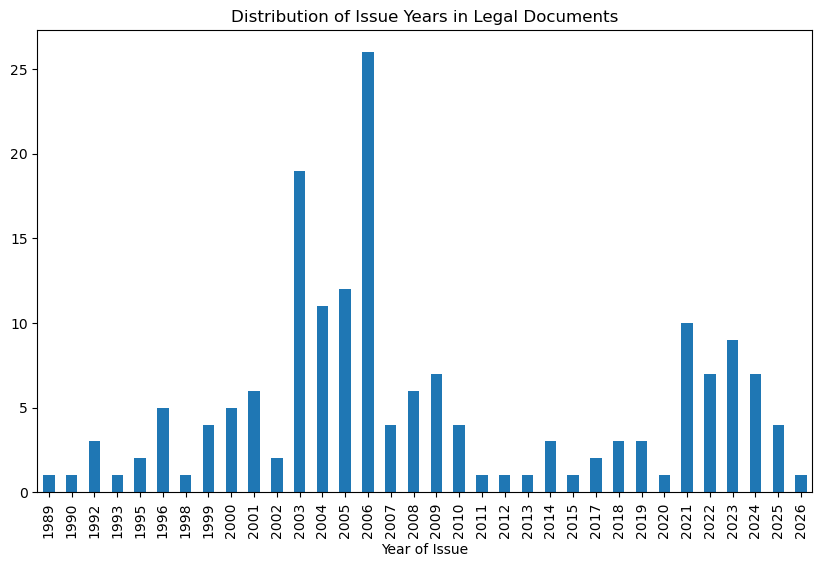

In [152]:
# Plot the distribution of published year in the education metadata
plt.figure(figsize=(10, 6))
legal_docs['year_of_issue'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Issue Years in Legal Documents')
plt.xlabel('Year of Issue')

In [158]:
# Remove row with published year before 2000
legal_docs = legal_docs[legal_docs['year_of_issue'] >= 2000]
print(legal_docs.shape)

(156, 17)


# Preprocessing content of the documents

In [161]:
print(legal_docs.info())
# legal_docs.drop(columns = 'ngay_het_hieu_luc', inplace= True)

<class 'pandas.DataFrame'>
Index: 156 entries, 2 to 275
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   156 non-null    int64         
 1   content_html         156 non-null    str           
 2   title                156 non-null    str           
 3   so_ky_hieu           156 non-null    str           
 4   ngay_ban_hanh        156 non-null    datetime64[us]
 5   loai_van_ban         156 non-null    str           
 6   ngay_co_hieu_luc     156 non-null    str           
 7   nguon_thu_thap       100 non-null    str           
 8   ngay_dang_cong_bao   156 non-null    str           
 9   nganh                156 non-null    str           
 10  linh_vuc             156 non-null    str           
 11  co_quan_ban_hanh     156 non-null    str           
 12  chuc_danh            156 non-null    str           
 13  nguoi_ky             156 non-null    str           

In [163]:
# Display the html content of the first document in the merged dataset  
print(legal_docs.iloc[0]['content_html']) 

print(legal_docs.iloc[0]['title'])

<table class="detailcontent" width="100%" border="0" id="content">
                <tr>
                    <td colspan="3">
                        <div align="justify">
                            <p align="center">
	<strong>QUYẾT ĐỊNH </strong></p>
<p align="center">
	<strong>Về việc ban hành tạm thời chương trình Đại học sư phạm Âm nhạc</strong></p>
<p align="center">
	<strong>BỘ TRƯỞNG BỘ GIÁO DỤC VÀ ĐÀO TẠO</strong></p>
<p>
	<em>Căn cứ vào Nghị định số 29/CP ngày 30 tháng 3 năm 1994 của Chính phủ về nhiệm vụ, quyền hạn và tổ chức bộ máy của Bộ Giáo dục và Đào tạo;</em></p>
<p>
	<em>Căn cứ vào Nghị định số 15/CP ngày 02 tháng 3 năm 1993 của Chính phủ về nhiệm vụ, quyền hạn và trách nhiệm quản lý Nhà nước của Bộ, cơ quan ngang Bộ;</em></p>
<p>
	<em>Căn cứ Thông tư Liên Bộ Giáo dục và Đào tạo - Văn hoá Thông tin số 15/TTLB ngày 21-8-1996 về việc phối hợp đào tạo và bồi dưỡng giáo viên Âm nhạc và Mĩ thuật phục vụ sự nghiệp giáo dục thẩm mĩ cho học sinh mẫu giáo, phổ thông;</em></p>
<

In [165]:
# Clean the content 
from bs4 import BeautifulSoup

def clean_html(html):
    soup = BeautifulSoup(html, "html.parser")
    
    # ❌ remove script, style
    for tag in soup(["script", "style"]):
        tag.decompose()
    
    # ❌ remove attributes (class, style,...)
    for tag in soup.find_all(True):
        tag.attrs = {}
    
    # ✅ lấy text
    text = soup.get_text(separator="\n")
    
    # ❌ remove dòng trống dư thừa
    text = re.sub(r'\n+', '\n', text)
    
    # ❌ strip space
    text = text.strip()
    
    return text

In [167]:
legal_docs['clean_content'] = legal_docs['content_html'].apply(clean_html)

In [169]:
legal_docs['clean_content'].iloc[0]

'QUYẾT ĐỊNH \nVề việc ban hành tạm thời chương trình Đại học sư phạm Âm nhạc\nBỘ TRƯỞNG BỘ GIÁO DỤC VÀ ĐÀO TẠO\nCăn cứ vào Nghị định số 29/CP ngày 30 tháng 3 năm 1994 của Chính phủ về nhiệm vụ, quyền hạn và tổ chức bộ máy của Bộ Giáo dục và Đào tạo;\nCăn cứ vào Nghị định số 15/CP ngày 02 tháng 3 năm 1993 của Chính phủ về nhiệm vụ, quyền hạn và trách nhiệm quản lý Nhà nước của Bộ, cơ quan ngang Bộ;\nCăn cứ Thông tư Liên Bộ Giáo dục và Đào tạo - Văn hoá Thông tin số 15/TTLB ngày 21-8-1996 về việc phối hợp đào tạo và bồi dưỡng giáo viên Âm nhạc và Mĩ thuật phục vụ sự nghiệp giáo dục thẩm mĩ cho học sinh mẫu giáo, phổ thông;\nTheo biên bản Hội đồng thẩm định ngày 10-6-1999;\nTheo đề nghị của Ông Vụ trưởng Vụ Giáo viên, Ông Vụ trưởng Vụ Đại học;\nQUYẾT ĐỊNH\nĐiều 1:\n Ban hành kèm theo Quyết định này "Chương trình Đại học sư phạm Âm nhạc" áp dụng tạm thời cho việc đào tạo cử nhân sư phạm Âm nhạc tại Nhạc viện Hà Nội và Nhạc viện Thành phố Hồ Chí Minh.\nĐiều 2:\n Chương trình này được thực h

In [170]:
legal_docs.to_csv('data/raw/legal_docs.csv', index=False)

# Preprocessing NEU PDF

In [184]:
legal_docs[legal_docs['nguoi_ky'] == 'Nguyễn Văn Phúc']

,id,content_html,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,tinh_trang_hieu_luc,year_of_issue,clean_content
135,153186,"<table class=""detailcontent"" width=""100%"" bord...",Bãi bỏ một số văn bản quy phạm pháp luật do Bộ...,46/2021/TT-BGDĐT,2021-12-31,Thông tư,15/02/2022,NaN,22/01/2022,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2021,THÔNG TƯ\nBãi bỏ một số văn bản quy phạm pháp ...
141,150078,"<table class=""detailcontent"" width=""100%"" bord...",Quy định về hoạt động nghiên cứu khoa học của ...,26/2021/TT-BGDĐT,2021-09-17,Thông tư,02/11/2021,NaN,07/10/2021,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2021,THÔNG TƯ \nQuy định về hoạt động nghiên cứu kh...
146,159090,"<table class=""detailcontent"" width=""100%"" bord...",Ban hành Danh mục thiết bị dạy học tối thiểu m...,19/2022/TT-BGDĐT,2022-12-22,Thông tư,06/02/2023,NaN,08/01/2023,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2022,THÔNG TƯ\nBan hành Danh\n mục thiết bị dạy học...
163,172452,"<table class=""detailcontent"" width=""100%"" bord...","Thông tư sửa đổi, bổ sung một số điều của Quy ...",20/2024/TT-BGDĐT,2024-11-28,Thông tư,14/01/2025,NaN,...,Giáo dục và đào tạo,"Quy chế thi, tuyển sinh",Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2024,"THÔNG TƯ\n Sửa đổi, bổ sung một số điều của Q..."
169,187111,"<table class=""detailcontent"" width=""100%"" bord...",Thông tư ban hành Quy chế tuyển sinh các ngành...,06/2026/TT-BGDĐT,2026-02-15,Thông tư,15/02/2026,NaN,...,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2026,THÔNG TƯ\n\tBAN HÀNH QUY CHẾ TUYỂN SINH CÁC NG...
269,144400,"<table class=""detailcontent"" width=""100%"" bord...",Ban hành Quy chế quản lý bằng tốt nghiệp trung...,21/2019/TT-BGDĐT,2019-11-29,Thông tư,15/01/2020,NaN,15/12/2019,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2019,THÔNG TƯ\nBan hành \nQuy chế quản lý bằng tốt ...
274,142785,"<table class=""detailcontent"" width=""100%"" bord...",Ban hành Chương trình giáo dục quốc phòng và a...,05/2020/TT-BGDĐT,2020-03-18,Thông tư,01/07/2020,Công báo CP,03/04/2020,Giáo dục và đào tạo,Giáo dục đại học,Bộ Giáo dục và Đào tạo,Thứ trưởng,Nguyễn Văn Phúc,Toàn quốc,Còn hiệu lực,2020,THÔNG TƯ\nBan hành Chương trình giáo dục quốc ...
